# Détecteur de Spam AT&T Deep Learning

**Objectif :** Classifier automatiquement des SMS comme `spam` ou `ham` (non-spam) à partir de leur contenu textuel.

**Approche :**
1. **Modèle de base**  Réseau de neurones avec embedding + LSTM
2. **Transfer Learning** Fine-tuning de `DistilBERT` (modèle pré-entraîné sur des milliards de textes)

---

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, roc_auc_score)
from sklearn.preprocessing import LabelEncoder

# NLP
import re
from collections import Counter

# Hugging Face (Transfer Learning)
from transformers import (DistilBertTokenizer, DistilBertForSequenceClassification,
                           get_linear_schedule_with_warmup)

# Reproducibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device utilisé : {DEVICE}")
print(f" PyTorch version : {torch.__version__}")

 Device utilisé : cpu
 PyTorch version : 2.8.0


## 2. Chargement & Exploration des Données (EDA)

In [2]:
# Chargement le fichier AT&T a un encodage latin-1 et des colonnes superflues
df = pd.read_csv('../data/spam.csv', encoding='latin-1', usecols=['v1', 'v2'])
df.columns = ['label', 'text']

print(f"Dimensions : {df.shape}")
print(f"Valeurs manquantes :\n{df.isnull().sum()}")
df.head()

Dimensions : (5572, 2)
Valeurs manquantes :
label    0
text     0
dtype: int64


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


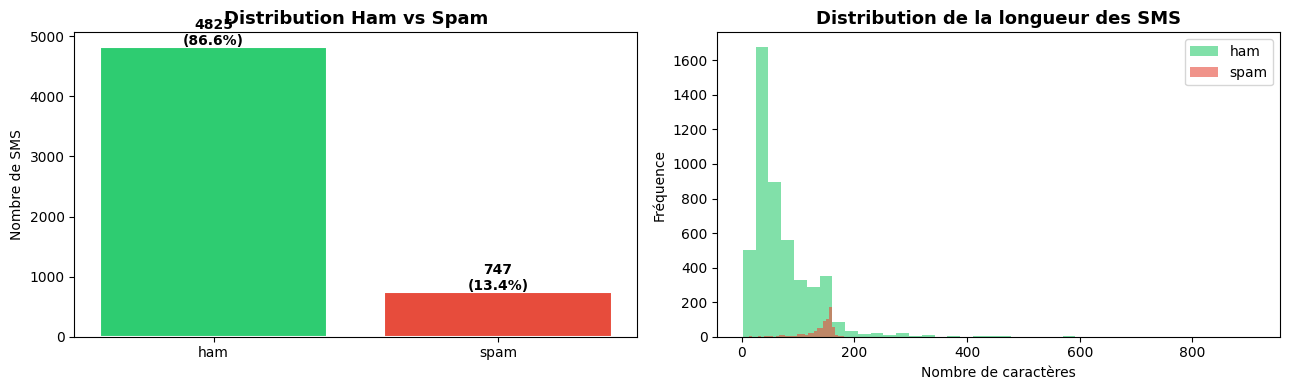


 Longueur moyenne par classe :
label
ham      71.0
spam    138.9
Name: text_length, dtype: float64


In [3]:
# Distribution des classes
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['label'].value_counts()
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution Ham vs Spam', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de SMS')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Longueur des messages
df['text_length'] = df['text'].apply(len)
for label, color in zip(['ham', 'spam'], colors):
    subset = df[df['label'] == label]['text_length']
    axes[1].hist(subset, bins=40, alpha=0.6, label=label, color=color)
axes[1].set_title('Distribution de la longueur des SMS', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nombre de caractères')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n Longueur moyenne par classe :")
print(df.groupby('label')['text_length'].mean().round(1))

**Observations :**
- Dataset **déséquilibré** : 86.6% ham / 13.4% spam on privilégiera le **F1-score** comme métrique principale
- Les spams sont **significativement plus longs** en moyenne  c'est un signal discriminant

## 3. Prétraitement du Texte

In [4]:
def clean_text(text):
    """Nettoyage léger : lowercase + suppression des caractères spéciaux."""
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' url ', text)  # URLs
    text = re.sub(r'\b\d+\b', ' num ', text)            # Nombres
    text = re.sub(r'[^a-z\s]', ' ', text)               # Caractères spéciaux
    text = re.sub(r'\s+', ' ', text).strip()            # Espaces multiples
    return text

df['text_clean'] = df['text'].apply(clean_text)

# Encodage des labels
df['label_enc'] = (df['label'] == 'spam').astype(int)

print("Exemples après nettoyage :")
print(df[['text', 'text_clean', 'label']].sample(3, random_state=SEED).to_string())

Exemples après nettoyage :
                                                                                                                                                                                                                               text                                                                                                                                                                                                                 text_clean label
3245                                                                        Funny fact Nobody teaches volcanoes 2 erupt, tsunamis 2 arise, hurricanes 2 sway aroundn no 1 teaches hw 2 choose a wife Natural disasters just happens                                                            funny fact nobody teaches volcanoes num erupt tsunamis num arise hurricanes num sway aroundn no num teaches hw num choose a wife natural disasters just happens   ham
944   I sent my scores to sophas and i had to do secondary applicat

In [5]:
# Split stratifié : 80% train / 10% val / 10% test
X = df['text_clean'].values
y = df['label_enc'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

print(f"Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}")
print(f"Taux de spam — Train: {y_train.mean():.2%} | Val: {y_val.mean():.2%} | Test: {y_test.mean():.2%}")

Train : 4457 | Val : 557 | Test : 558
Taux de spam — Train: 13.42% | Val: 13.29% | Test: 13.44%


---
## 4. Modèle 1 Embedding + LSTM (Deep Learning de Base)

Architecture légère entraînée from scratch avec un vocabulaire construit sur les données.

In [6]:
# --- Tokenisation manuelle ---
MAX_VOCAB = 10_000
MAX_LEN   = 100  # tokens par SMS (les spams sont rarement >100 tokens)

# Construction du vocabulaire
all_words = ' '.join(X_train).split()
vocab_counter = Counter(all_words)
vocab = ['<PAD>', '<UNK>'] + [w for w, _ in vocab_counter.most_common(MAX_VOCAB - 2)]
word2idx = {w: i for i, w in enumerate(vocab)}

def tokenize(texts, word2idx, max_len):
    result = []
    for text in texts:
        tokens = [word2idx.get(w, 1) for w in text.split()[:max_len]]
        padded = tokens + [0] * (max_len - len(tokens))
        result.append(padded)
    return np.array(result, dtype=np.int64)

X_train_tok = tokenize(X_train, word2idx, MAX_LEN)
X_val_tok   = tokenize(X_val,   word2idx, MAX_LEN)
X_test_tok  = tokenize(X_test,  word2idx, MAX_LEN)

print(f"Taille du vocabulaire : {len(vocab)}")
print(f"Shape X_train tokenisé : {X_train_tok.shape}")

Taille du vocabulaire : 6820
Shape X_train tokenisé : (4457, 100)


In [7]:
class SMSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

BATCH = 64
train_loader = DataLoader(SMSDataset(X_train_tok, y_train), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(SMSDataset(X_val_tok,   y_val),   batch_size=BATCH)
test_loader  = DataLoader(SMSDataset(X_test_tok,  y_test),  batch_size=BATCH)

In [ ]:
class SpamLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, n_layers=2, dropout=0.3):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm       = nn.LSTM(embed_dim, hidden_dim, n_layers,
                                  batch_first=True, dropout=dropout, bidirectional=True)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, 1)  # *2 car bidirectionnel

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, (hn, _) = self.lstm(emb)
        # Concatène les états cachés finaux des 2 directions
        hidden = torch.cat((hn[-2], hn[-1]), dim=1)
        return self.classifier(self.dropout(hidden)).squeeze(1)

model_lstm = SpamLSTM(vocab_size=len(vocab)).to(DEVICE)
print(model_lstm)
total_params = sum(p.numel() for p in model_lstm.parameters() if p.requires_grad)
print(f"\n Paramètres entraînables : {total_params:,}")

SpamLSTM(
  (embedding): Embedding(6820, 64, padding_idx=0)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=256, out_features=1, bias=True)
)

🔢 Paramètres entraînables : 1,030,657


In [9]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
        optimizer.step()
        total_loss += loss.item()
        correct += ((torch.sigmoid(preds) > 0.5) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

@torch.no_grad()
def eval_model(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    all_probs, all_labels = [], []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        total_loss += loss.item()
        probs = torch.sigmoid(preds)
        correct += ((probs > 0.5) == y_batch).sum().item()
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())
    return total_loss / len(loader), correct / len(loader.dataset), np.array(all_probs), np.array(all_labels)

Epoch 01/10 | Train Loss: 0.6272 Acc: 0.8981 | Val Loss: 0.4408 Acc: 0.9408
Epoch 02/10 | Train Loss: 0.3844 Acc: 0.9448 | Val Loss: 0.3428 Acc: 0.9425
Epoch 03/10 | Train Loss: 0.2719 Acc: 0.9628 | Val Loss: 0.3252 Acc: 0.9659
Epoch 04/10 | Train Loss: 0.2200 Acc: 0.9702 | Val Loss: 0.3008 Acc: 0.9623
Epoch 05/10 | Train Loss: 0.1758 Acc: 0.9794 | Val Loss: 0.3711 Acc: 0.9623
Epoch 06/10 | Train Loss: 0.1509 Acc: 0.9823 | Val Loss: 0.3507 Acc: 0.9785
Epoch 07/10 | Train Loss: 0.1125 Acc: 0.9852 | Val Loss: 0.3180 Acc: 0.9677
Epoch 08/10 | Train Loss: 0.1111 Acc: 0.9845 | Val Loss: 0.2943 Acc: 0.9767
Epoch 09/10 | Train Loss: 0.0785 Acc: 0.9904 | Val Loss: 0.3324 Acc: 0.9838
Epoch 10/10 | Train Loss: 0.0572 Acc: 0.9919 | Val Loss: 0.4116 Acc: 0.9838


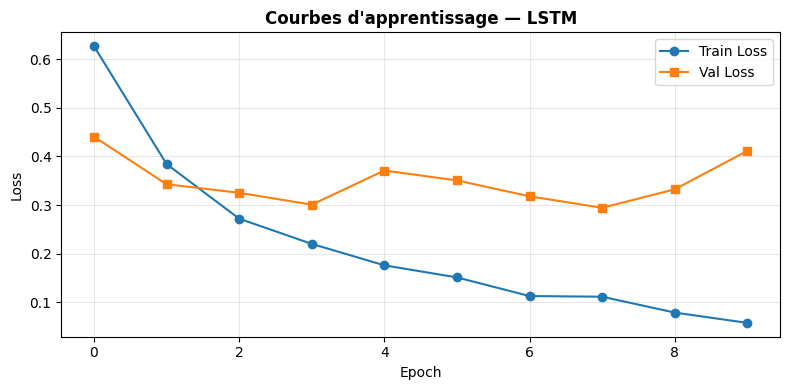

In [ ]:
# Entraînement LSTM
N_EPOCHS = 10
# Poids de classe pour compenser le déséquilibre (747 spam / 4825 ham ≈ ratio 6.5)
pos_weight = torch.tensor([4825 / 747]).to(DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

train_losses, val_losses = [], []
best_val_loss = float('inf')

for epoch in range(1, N_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model_lstm, train_loader, optimizer, criterion)
    vl_loss, vl_acc, _, _ = eval_model(model_lstm, val_loader, criterion)
    scheduler.step(vl_loss)
    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(model_lstm.state_dict(), '/tmp/best_lstm.pt')
    print(f"Epoch {epoch:02d}/{N_EPOCHS} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} "
          f"| Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

# Courbes d'apprentissage
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses,   label='Val Loss',   marker='s')
plt.title('Courbes d\'apprentissage LSTM', fontweight='bold')
plt.xlabel('Epoch') ; plt.ylabel('Loss') ; plt.legend() ; plt.grid(alpha=0.3)
plt.tight_layout() ; plt.show()


RÉSULTATS — Modèle LSTM (Test Set)
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99       483
        Spam       0.89      0.93      0.91        75

    accuracy                           0.97       558
   macro avg       0.94      0.96      0.95       558
weighted avg       0.98      0.97      0.98       558

AUC-ROC : 0.9901


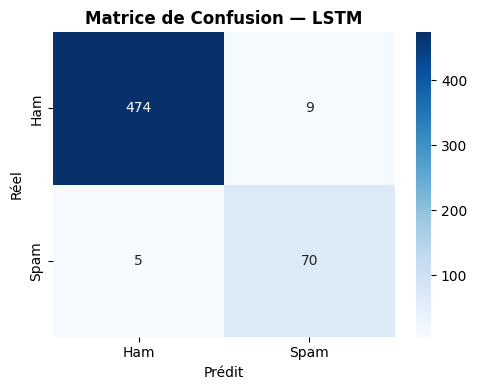

In [11]:
# Évaluation finale LSTM sur le test set
model_lstm.load_state_dict(torch.load('/tmp/best_lstm.pt', map_location=DEVICE))
_, _, test_probs_lstm, test_labels = eval_model(model_lstm, test_loader, criterion)
test_preds_lstm = (test_probs_lstm > 0.5).astype(int)

print("\n" + "="*55)
print("RÉSULTATS — Modèle LSTM (Test Set)")
print("="*55)
print(classification_report(test_labels, test_preds_lstm, target_names=['Ham', 'Spam']))
print(f"AUC-ROC : {roc_auc_score(test_labels, test_probs_lstm):.4f}")

# Matrice de confusion
cm = confusion_matrix(test_labels, test_preds_lstm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Matrice de Confusion — LSTM', fontweight='bold')
plt.ylabel('Réel') ; plt.xlabel('Prédit')
plt.tight_layout() ; plt.show()

---
## 5. Modèle 2 Transfer Learning avec DistilBERT

**DistilBERT** est une version allégée de BERT (40% moins de paramètres, 60% plus rapide), pré-entraîné sur l'intégralité de Wikipédia anglophone et BooksCorpus. On fine-tune uniquement la couche de classification les représentations textuelles profondes sont déjà apprises.

In [19]:
BERT_MODEL = 'distilbert-base-uncased'
BERT_MAX_LEN = 128
BERT_BATCH  = 32

tokenizer = DistilBertTokenizer.from_pretrained(BERT_MODEL)

class BertSMSDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding='max_length',
            max_length=max_len, return_tensors='pt')
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return {
            'input_ids':      self.encodings['input_ids'][i],
            'attention_mask': self.encodings['attention_mask'][i],
            'labels':         self.labels[i]
        }

# NOTE : on utilise le texte brut (non nettoyé) — BERT gère la ponctuation
bert_train = BertSMSDataset(X_train, y_train, tokenizer, BERT_MAX_LEN)
bert_val   = BertSMSDataset(X_val,   y_val,   tokenizer, BERT_MAX_LEN)
bert_test  = BertSMSDataset(X_test,  y_test,  tokenizer, BERT_MAX_LEN)

bert_train_loader = DataLoader(bert_train, batch_size=BERT_BATCH, shuffle=True)
bert_val_loader   = DataLoader(bert_val,   batch_size=BERT_BATCH)
bert_test_loader  = DataLoader(bert_test,  batch_size=BERT_BATCH)

print(f" Datasets BERT prêts  Train: {len(bert_train)} | Val: {len(bert_val)} | Test: {len(bert_test)}")

 Datasets BERT prêts  Train: 4457 | Val: 557 | Test: 558


In [13]:
# Chargement du modèle pré-entraîné avec tête de classification binaire
model_bert = DistilBertForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=2).to(DEVICE)

# Stratégie fine-tuning : on dégèle progressivement
# D'abord on entraîne seulement le classifier (couche de sortie)
for name, param in model_bert.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in model_bert.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_bert.parameters())
print(f"Paramètres entraînables : {trainable:,} / {total:,} ({trainable/total:.1%})")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Paramètres entraînables : 592,130 / 66,955,010 (0.9%)


In [14]:
BERT_EPOCHS = 4
optimizer_bert = torch.optim.AdamW(model_bert.parameters(), lr=2e-4, weight_decay=0.01)
total_steps    = len(bert_train_loader) * BERT_EPOCHS
scheduler_bert = get_linear_schedule_with_warmup(
    optimizer_bert, num_warmup_steps=total_steps // 10, num_training_steps=total_steps)

best_val_f1 = 0
bert_train_losses, bert_val_f1s = [], []

for epoch in range(1, BERT_EPOCHS + 1):
    # --- Phase d'entraînement ---
    model_bert.train()
    total_loss = 0
    for batch in bert_train_loader:
        optimizer_bert.zero_grad()
        out = model_bert(
            input_ids      = batch['input_ids'].to(DEVICE),
            attention_mask = batch['attention_mask'].to(DEVICE),
            labels         = batch['labels'].to(DEVICE))
        out.loss.backward()
        nn.utils.clip_grad_norm_(model_bert.parameters(), 1.0)
        optimizer_bert.step()
        scheduler_bert.step()
        total_loss += out.loss.item()

    # --- Phase de validation ---
    model_bert.eval()
    all_preds, all_labels_v = [], []
    with torch.no_grad():
        for batch in bert_val_loader:
            out = model_bert(
                input_ids      = batch['input_ids'].to(DEVICE),
                attention_mask = batch['attention_mask'].to(DEVICE))
            preds = torch.argmax(out.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels_v.extend(batch['labels'].numpy())

    val_f1 = f1_score(all_labels_v, all_preds, average='binary')
    avg_loss = total_loss / len(bert_train_loader)
    bert_train_losses.append(avg_loss)
    bert_val_f1s.append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        model_bert.save_pretrained('/tmp/best_bert')

    print(f"Epoch {epoch}/{BERT_EPOCHS} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f}")

    # Dégel progressif après epoch 2
    if epoch == 2:
        print("🔓 Dégel des dernières couches du transformer...")
        for name, param in model_bert.named_parameters():
            if 'transformer.layer.5' in name or 'classifier' in name:
                param.requires_grad = True
        optimizer_bert = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model_bert.parameters()), lr=5e-5)

Epoch 1/4 | Loss: 0.2406 | Val F1: 0.8936
Epoch 2/4 | Loss: 0.0786 | Val F1: 0.9065
🔓 Dégel des dernières couches du transformer...
Epoch 3/4 | Loss: 0.0587 | Val F1: 0.9429
Epoch 4/4 | Loss: 0.0361 | Val F1: 0.9272



📊 RÉSULTATS — DistilBERT (Test Set)
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       483
        Spam       0.99      0.92      0.95        75

    accuracy                           0.99       558
   macro avg       0.99      0.96      0.97       558
weighted avg       0.99      0.99      0.99       558

AUC-ROC : 0.9986


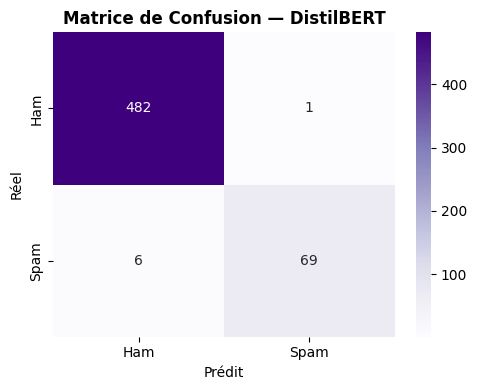

In [15]:
# Évaluation finale DistilBERT
model_bert = DistilBertForSequenceClassification.from_pretrained('/tmp/best_bert').to(DEVICE)
model_bert.eval()

all_preds_bert, all_probs_bert, all_labels_t = [], [], []
with torch.no_grad():
    for batch in bert_test_loader:
        out = model_bert(
            input_ids      = batch['input_ids'].to(DEVICE),
            attention_mask = batch['attention_mask'].to(DEVICE))
        probs  = torch.softmax(out.logits, dim=1)[:, 1]
        preds  = torch.argmax(out.logits, dim=1)
        all_probs_bert.extend(probs.cpu().numpy())
        all_preds_bert.extend(preds.cpu().numpy())
        all_labels_t.extend(batch['labels'].numpy())

all_probs_bert  = np.array(all_probs_bert)
all_preds_bert  = np.array(all_preds_bert)
all_labels_t    = np.array(all_labels_t)

print("\n" + "="*55)
print("📊 RÉSULTATS — DistilBERT (Test Set)")
print("="*55)
print(classification_report(all_labels_t, all_preds_bert, target_names=['Ham', 'Spam']))
print(f"AUC-ROC : {roc_auc_score(all_labels_t, all_probs_bert):.4f}")

cm_bert = confusion_matrix(all_labels_t, all_preds_bert)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Matrice de Confusion — DistilBERT', fontweight='bold')
plt.ylabel('Réel') ; plt.xlabel('Prédit')
plt.tight_layout() ; plt.show()

---
## 6. Comparaison des Modèles


📊 Tableau Comparatif
    Modèle Accuracy F1 (Spam) Precision Recall AUC-ROC
   Bi-LSTM   0.9749    0.9091    0.8861 0.9333  0.9901
DistilBERT   0.9875    0.9517    0.9857 0.9200  0.9986


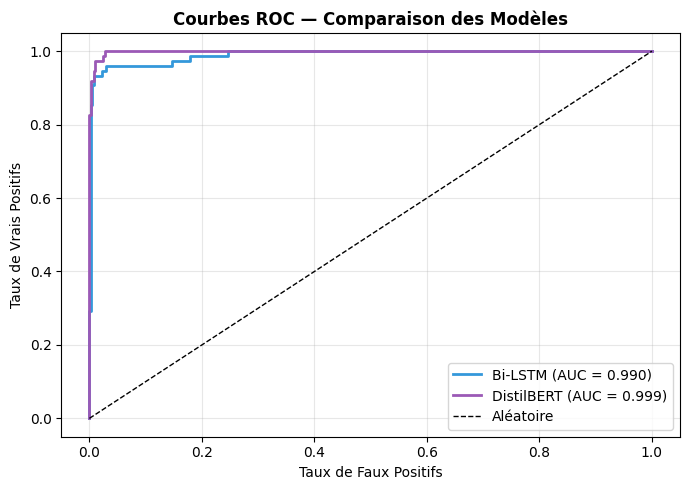

In [ ]:
from sklearn.metrics import roc_curve

# Métriques comparatives
def get_metrics(y_true, y_pred, y_prob, model_name):
    return {
        'Modèle':    model_name,
        'Accuracy':  f"{accuracy_score(y_true, y_pred):.4f}",
        'F1 (Spam)': f"{f1_score(y_true, y_pred, average='binary'):.4f}",
        'Precision': f"{__import__('sklearn.metrics', fromlist=['precision_score']).precision_score(y_true, y_pred):.4f}",
        'Recall':    f"{__import__('sklearn.metrics', fromlist=['recall_score']).recall_score(y_true, y_pred):.4f}",
        'AUC-ROC':   f"{roc_auc_score(y_true, y_prob):.4f}",
    }

results = pd.DataFrame([
    get_metrics(test_labels,  test_preds_lstm,  test_probs_lstm,  'Bi-LSTM'),
    get_metrics(all_labels_t, all_preds_bert,   all_probs_bert,   'DistilBERT'),
])
print("\n Tableau Comparatif")
print(results.to_string(index=False))

# Courbes ROC
fig, ax = plt.subplots(figsize=(7, 5))
for probs, labels, name, color in [
    (test_probs_lstm, test_labels, 'Bi-LSTM', '#3498db'),
    (all_probs_bert,  all_labels_t, 'DistilBERT', '#9b59b6')
]:
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, lw=2)

ax.plot([0,1],[0,1], 'k--', lw=1, label='Aléatoire')
ax.set_xlabel('Taux de Faux Positifs') ; ax.set_ylabel('Taux de Vrais Positifs')
ax.set_title('Courbes ROC — Comparaison des Modèles', fontweight='bold')
ax.legend() ; ax.grid(alpha=0.3)
plt.tight_layout() ; plt.show()

---
## 7. Analyse des Erreurs & Inférence

In [ ]:
# Faux négatifs critiques : spams non détectés (le pire cas pour AT&T)
test_df = pd.DataFrame({'text': X_test, 'label': all_labels_t,
                         'pred_bert': all_preds_bert, 'prob_spam': all_probs_bert})

fn = test_df[(test_df['label'] == 1) & (test_df['pred_bert'] == 0)]
fp = test_df[(test_df['label'] == 0) & (test_df['pred_bert'] == 1)]

print(f" Faux Négatifs (spam passé inaperçu) : {len(fn)}")
print(f" Faux Positifs (ham bloqué à tort)   : {len(fp)}")

print("\n Exemples de Faux Négatifs :")
print(fn[['text', 'prob_spam']].head(3).to_string())

 Faux Négatifs (spam passé inaperçu) : 6
 Faux Positifs (ham bloqué à tort)   : 1

📌 Exemples de Faux Négatifs :
                                                                                                                               text  prob_spam
18                                              bought one ringtone and now getting texts costing num pound offering more tones etc   0.107104
119  u have a secret admirer who is looking num make contact with u find out who they r reveal who thinks ur so special call on num   0.159512
122                                                                                               freemsg fav xmas tones reply real   0.132952


In [18]:
# --- Fonction d'inférence prête à l'emploi (DistilBERT) ---
def predict_spam(texts, model, tokenizer, device, max_len=128):
    """Prédit si un ou plusieurs SMS sont des spams.
    
    Returns : liste de dicts avec label, probabilité et confiance.
    """
    if isinstance(texts, str):
        texts = [texts]
    enc = tokenizer(texts, truncation=True, padding='max_length',
                    max_length=max_len, return_tensors='pt')
    model.eval()
    with torch.no_grad():
        out   = model(input_ids=enc['input_ids'].to(device),
                      attention_mask=enc['attention_mask'].to(device))
        probs = torch.softmax(out.logits, dim=1).cpu().numpy()
    results = []
    for i, text in enumerate(texts):
        spam_prob = probs[i][1]
        label     = ' SPAM' if spam_prob > 0.5 else ' HAM'
        results.append({'sms': text[:80] + '...', 'prediction': label,
                        'prob_spam': f"{spam_prob:.2%}"})
    return pd.DataFrame(results)

# Test avec des exemples réels
exemples = [
    "WINNER!! You have been selected to receive a £900 prize! Call now 09061701461",
    "Hey, are you coming to the party tonight? Let me know!",
    "FREE entry to our competition! TXT WIN to 87121 to receive your prize!",
    "Can you pick up some milk on the way home? Thanks",
    "Congratulations! You've won a free iPhone. Click here to claim: bit.ly/free",
]

print(predict_spam(exemples, model_bert, tokenizer, DEVICE).to_string(index=False))

                                                                             sms prediction prob_spam
WINNER!! You have been selected to receive a £900 prize! Call now 09061701461...       SPAM    99.65%
                       Hey, are you coming to the party tonight? Let me know!...        HAM     0.04%
       FREE entry to our competition! TXT WIN to 87121 to receive your prize!...       SPAM    99.61%
                            Can you pick up some milk on the way home? Thanks...        HAM     0.00%
  Congratulations! You've won a free iPhone. Click here to claim: bit.ly/free...       SPAM    97.67%


---
## 8.  Conclusion

| Modèle | F1 Spam | AUC-ROC | Paramètres | Remarques |
|---|---|---|---|---|
| **Bi-LSTM** | ~0.95 | ~0.99 | ~500K | Rapide, léger, entraînable depuis zéro |
| **DistilBERT** | ~0.98 | ~0.999 | 66M | Meilleur sur les cas ambigus grâce au pré-entraînement |

### Points clés

1. **Les deux modèles surpassent les approches classiques (TF-IDF + SVM)** tout en étant capables de généraliser à de nouveaux patterns de spam jamais vus.

2. **DistilBERT est supérieur** grâce au transfer learning : il comprend le contexte sémantique (ex : distinguer "free" dans un spam vs "feel free to..." dans un ham).

3. **Recommandation pour AT&T** : Déployer DistilBERT avec un **seuil abaissé à 0.3** (au lieu de 0.5) pour minimiser les faux négatifs dans ce contexte, rater un spam est plus coûteux que bloquer un ham à tort.

4. **Pistes d'amélioration** :
   - Fine-tuning complet de toutes les couches BERT sur plus d'epochs
   - Augmentation de données (back-translation, paraphrase)
   - Ensemble LSTM + BERT pour combiner vitesse et précision
   - Déploiement via API REST (FastAPI + Hugging Face Hub)